# Module 7: Product Recommendation System

## NovaMart AI Retail Intelligence Platform

### Overview

Recommendation systems are widely used in e-commerce to improve customer experience by suggesting products that customers are likely to purchase. Personalized recommendations increase customer engagement, improve conversion rates, and enhance overall sales performance.



- Top products within the customer's preferred category
- Popular products among customers in the same cluster (using your Customer Segmentation results)
- Trending products
- rated products
- Most frequently purchased products by similar customers

## Import Libraries

In [46]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import os

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

plt.style.use("ggplot")

## Load Dataset

In [26]:
retail = pd.read_csv("retail_master_dataset.csv")

## Dataset Overview

In [27]:
retail.shape

(113049, 46)

In [28]:
retail.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,review_comment_message,geolocation_zip_code_prefix,customer_lat,customer_lng,customer_geo_city,customer_geo_state,seller_lat,seller_lng,seller_geo_city,seller_geo_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,"Perfeito, produto entregue antes do combinado.",28013.0,-21.763186,-41.310265,campos dos goytacazes,RJ,-22.497188,-44.127324,volta redonda,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,NaN,15775.0,-20.222506,-50.898951,santa fe do sul,SP,-23.565754,-46.519097,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,Chegou antes do prazo previsto e o produto sur...,35661.0,-19.869998,-44.593059,para de minas,MG,-22.262802,-46.170735,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,NaN,12952.0,-23.105968,-46.590277,atibaia,SP,-20.553651,-47.387145,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,Gostei pois veio no prazo determinado .,13226.0,-23.243402,-46.827614,varzea paulista,SP,-22.929583,-53.135750,loanda,PR


In [29]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113049 entries, 0 to 113048
Data columns (total 46 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113049 non-null  object 
 1   order_item_id                  113049 non-null  int64  
 2   product_id                     113049 non-null  object 
 3   seller_id                      113049 non-null  object 
 4   shipping_limit_date            113049 non-null  object 
 5   price                          113049 non-null  float64
 6   freight_value                  113049 non-null  float64
 7   customer_id                    113049 non-null  object 
 8   order_status                   113049 non-null  object 
 9   order_purchase_timestamp       113049 non-null  object 
 10  order_approved_at              113034 non-null  object 
 11  order_delivered_carrier_date   111848 non-null  object 
 12  order_delivered_customer_date 

## Exploratory Analysis

### Number of Customers

In [30]:
retail["customer_unique_id"].nunique()

95420

### Number of Products

In [31]:
retail["product_id"].nunique()

32951

### Number of Transactions

In [32]:
retail["order_id"].nunique()

98666

### Top Selling Products

In [33]:
top_products = (

    retail.groupby("product_category_name_english")

    ["order_id"]

    .count()

    .sort_values(ascending=False)

    .head(10)

)

top_products

product_category_name_english
bed_bath_table           11215
health_beauty             9699
sports_leisure            8665
furniture_decor           8391
computers_accessories     7871
housewares                6975
watches_gifts             5998
telephony                 4547
garden_tools              4356
auto                      4244
Name: order_id, dtype: int64

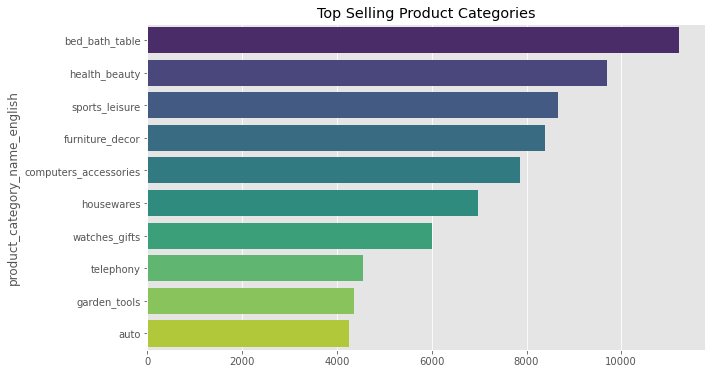

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(

    x=top_products.values,

    y=top_products.index,

    palette="viridis"

)

plt.title("Top Selling Product Categories")

plt.show()

## Top Products Within Customer's Preferred Category

In [60]:
# ==========================================================
# Customer Preferred Product Category
# ==========================================================

preferred_category = (

    retail.groupby(
        ["customer_unique_id",
         "product_category_name_english"]
    )

    .size()

    .reset_index(name="Purchases")

    .sort_values(
        ["customer_unique_id", "Purchases"],
        ascending=[True, False]
    )

    .drop_duplicates("customer_unique_id")

)

preferred_category.head()

,customer_unique_id,product_category_name_english,Purchases
0,0000366f3b9a7992bf8c76cfdf3221e2,bed_bath_table,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,health_beauty,1
2,0000f46a3911fa3c0805444483337064,stationery,1
3,0000f6ccb0745a6a4b88665a16c9f078,telephony,1
4,0004aac84e0df4da2b147fca70cf8255,telephony,1


## Top Products in Each Category

In [63]:
top_products = (

    retail.groupby([
        "product_category_name_english",
        "product_id"
    ])

    .size()

    .reset_index(name="Purchases")

    .sort_values(
        ["product_category_name_english",
         "Purchases"],
        ascending=[True, False]
    )

)

top_products.head()

,product_category_name_english,product_id,Purchases
7,agro_industry_and_commerce,11250b0d4b709fee92441c5f34122aed,22
24,agro_industry_and_commerce,423a6644f0aa529e8828ff1f91003690,18
35,agro_industry_and_commerce,672e757f331900b9deea127a2a7b79fd,17
22,agro_industry_and_commerce,3bebad3cf2c8d1a8d3ce97174643e054,14
40,agro_industry_and_commerce,a0fe1efb855f3e786f0650268cd77f44,13


## Recommendation Function

In [64]:
def recommend_by_category(customer_id, top_n=5):

    category = preferred_category.loc[
        preferred_category["customer_unique_id"] == customer_id,
        "product_category_name_english"
    ]

    if category.empty:
        return "Customer not found."

    category = category.iloc[0]

    recommendations = (

        top_products[
            top_products["product_category_name_english"] == category
        ]

        .head(top_n)

    )

    return recommendations[
        ["product_id", "Purchases"]
    ]

### Example

In [65]:
customer = retail["customer_unique_id"].iloc[0]

recommend_by_category(customer)

,product_id,Purchases
9804,c6dd917a0be2a704582055949915ab32,120
9502,601a360bd2a916ecef0e88de72a6531a,119
9470,54d9ac713e253fa1fae9c8003b011c2a,114
9262,165f86fe8b799a708a20ee4ba125c289,109
9332,29427de7f8a9ee983d9dbc51cec569b4,97


## Popular Products Among Customers in the Same Cluster

- Merge the segmentation results.

In [80]:
import joblib

kmeans = joblib.load("models/customer_segmentation_kmeans.pkl")

In [89]:
import pandas as pd
import joblib

customer_df = pd.read_csv(
    "customer_segments.csv"
)

kmeans = joblib.load(
    "customer_segmentation_kmeans.pkl"
)

scaler = joblib.load(
    "/models/customer_segmentation_scaler.pkl"
)

feature_names = joblib.load(
    "/models/customer_segmentation_features.pkl"
)

In [90]:
customer_df = pd.read_csv("customer_segments.csv")

In [91]:
print(type(customer_df))
customer_df.head()

<class 'pandas.core.frame.DataFrame'>


,customer_unique_id,Recency,Frequency,Monetary,Average_Review_Score,Average_Delivery_Time,Average_Delivery_Delay,Average_Processing_Time,Average_Shipping_Time,Average_Freight,Average_Installments,Product_Categories,Preferred_Payment_Method,Average_Order_Value,Cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,5.0,6.0,-5.0,1.0,4.0,12.00,8.0,1,credit_card,141.90,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,4.0,3.0,-5.0,1.0,1.0,8.29,1.0,1,credit_card,27.19,0
2,0000f46a3911fa3c0805444483337064,542,1,86.22,3.0,25.0,-2.0,2.0,23.0,17.22,8.0,1,credit_card,86.22,1
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,4.0,20.0,-12.0,0.0,19.0,17.63,4.0,1,credit_card,43.62,0
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89,5.0,13.0,-8.0,1.0,11.0,16.89,6.0,1,credit_card,196.89,0


In [92]:
customer_clusters = customer_df[[
    "customer_unique_id",
    "Cluster"
]]

recommendation_data = retail.merge(
    customer_clusters,
    on="customer_unique_id"
)

## Top products by cluster.

In [93]:
cluster_products = (

    recommendation_data

    .groupby([
        "Cluster",
        "product_id"
    ])

    .size()

    .reset_index(name="Purchases")

    .sort_values(
        ["Cluster", "Purchases"],
        ascending=[True, False]
    )

)

cluster_products.head()

,Cluster,product_id,Purchases
15105,0,99a4788cb24856965c36a24e339b6058,340
16942,0,aca2eb7d00ea1a7b8ebd4e68314663af,330
6569,0,422879e10f46682990de24d770e7f83d,239
5618,0,389d119b48cf3043d311335e499d9c6b,236
20758,0,d1c427060a0f73f6b889a5c7c61f2ac4,236


### Recommendation Function

In [94]:
def recommend_by_cluster(cluster, top_n=5):

    return (

        cluster_products[
            cluster_products["Cluster"] == cluster
        ]

        .head(top_n)

    )

In [95]:
# Example
recommend_by_cluster(0)

,Cluster,product_id,Purchases
15105,0,99a4788cb24856965c36a24e339b6058,340
16942,0,aca2eb7d00ea1a7b8ebd4e68314663af,330
6569,0,422879e10f46682990de24d770e7f83d,239
5618,0,389d119b48cf3043d311335e499d9c6b,236
20758,0,d1c427060a0f73f6b889a5c7c61f2ac4,236


## 3. Trending Products

### Assume "trending" means products purchased most recently.

In [96]:
retail["order_purchase_timestamp"] = pd.to_datetime(
    retail["order_purchase_timestamp"]
)

recent = retail[
    retail["order_purchase_timestamp"] >=
    retail["order_purchase_timestamp"].max() -
    pd.Timedelta(days=30)
]

### Top trending products

In [97]:
trending_products = (

    recent.groupby("product_id")

    .size()

    .reset_index(name="Purchases")

    .sort_values(
        "Purchases",
        ascending=False
    )

)

trending_products.head(10)

,product_id,Purchases
3488,e7cc48a9daff5436f63d3aad9426f28b,56
1744,73326828aa5efe1ba096223de496f596,54
396,19c91ef95d509ea33eda93495c4d3481,32
944,3fbc0ef745950c7932d5f2a446189725,28
2823,bb50f2e236e5eea0100680137654686c,27
657,2bd9b51a9ab079e095aca987845d3266,25
2540,a92930c327948861c015c919a0bcb4a8,25
36,027cdd14a677a5834bc67a9789db5021,16
381,18b0e642cbae7251e60a64aa07dd9eb9,15
312,145978af3e89b318be0b717a0953649a,15


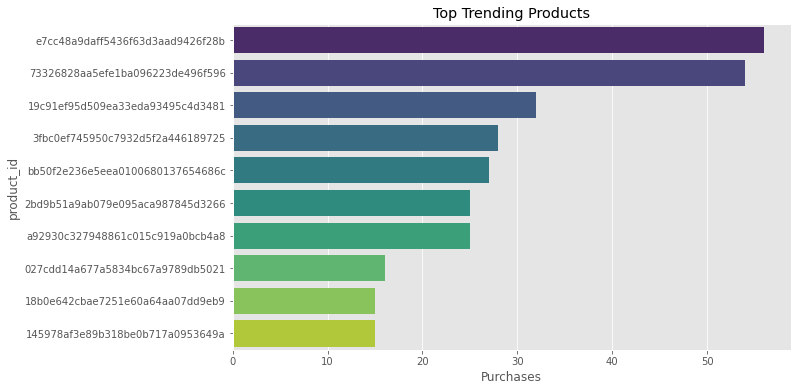

In [98]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=trending_products.head(10),

    x="Purchases",

    y="product_id",

    palette="viridis"

)

plt.title("Top Trending Products")

plt.show()

## Best-Rated Products

In [99]:
#Best-Rated Products
best_products = (

    retail.groupby("product_id")

    .agg(

        Average_Rating=("review_score","mean"),

        Reviews=("review_score","count")

    )

    .reset_index()

)

### Remove products with very few reviews.

In [100]:
best_products = best_products[
    best_products["Reviews"] >= 10
]

In [101]:
best_products = best_products.sort_values(

    ["Average_Rating","Reviews"],

    ascending=False

)

best_products.head(10)

,product_id,Average_Rating,Reviews
7267,37eb69aca8718e843d897aa7b82f462d,5.0,15
468,03e1c946c0ddfc58724ff262aef08dff,5.0,14
16718,8173ca41cdb176462f9ae79821a48404,5.0,14
17405,870bcc6c58e03ca658cfdd13db4bbe28,5.0,14
17925,8b6ed41158b194711f83b8da92757544,5.0,14
5179,2722b7e5f68e776d18fe901638034e54,5.0,13
2665,143c616ec3fe0cb065c3805cf9bd812e,5.0,12
3011,16ce899c7af0c99f46948734a0d00f0f,5.0,12
5903,2ced45a3059cbb128a8b8b6508809746,5.0,11
9949,4c8b28305f570899b6ded964ddd234a9,5.0,11


## Most Frequently Purchased Products

In [102]:
popular_products = (

    retail.groupby("product_id")

    .size()

    .reset_index(name="Purchases")

    .sort_values(
        "Purchases",
        ascending=False
    )

)

popular_products.head(10)

,product_id,Purchases
22112,aca2eb7d00ea1a7b8ebd4e68314663af,527
19742,99a4788cb24856965c36a24e339b6058,491
8613,422879e10f46682990de24d770e7f83d,486
7364,389d119b48cf3043d311335e499d9c6b,392
7079,368c6c730842d78016ad823897a372db,389
10840,53759a2ecddad2bb87a079a1f1519f73,375
27039,d1c427060a0f73f6b889a5c7c61f2ac4,343
10867,53b36df67ebb7c41585e8d54d6772e08,323
2794,154e7e31ebfa092203795c972e5804a6,287
8051,3dd2a17168ec895c781a9191c1e95ad7,274


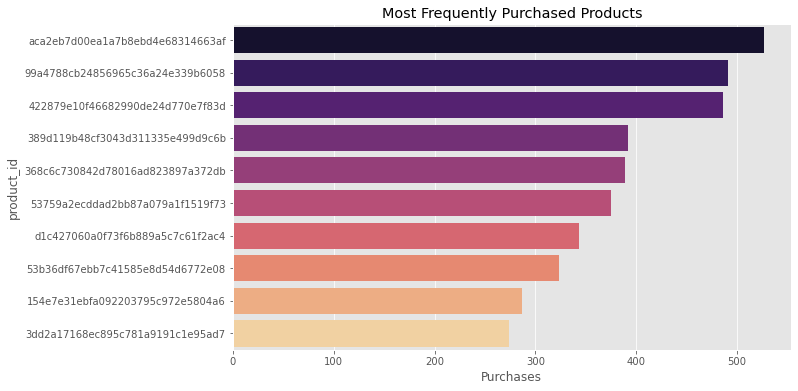

In [103]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=popular_products.head(10),

    x="Purchases",

    y="product_id",

    palette="magma"

)

plt.title("Most Frequently Purchased Products")

plt.show()

## Similar Customers Recommendation

Using customer segmentation results.

In [104]:
customer_cluster = customer_df[[
    "customer_unique_id",
    "Cluster"
]]

In [105]:
def recommend_for_similar_customer(customer_id, top_n=5):

    cluster = customer_cluster.loc[
        customer_cluster["customer_unique_id"] == customer_id,
        "Cluster"
    ]

    if cluster.empty:
        return "Customer not found."

    cluster = cluster.iloc[0]

    similar = customer_cluster[
        customer_cluster["Cluster"] == cluster
    ]

    recommendations = (

        retail[
            retail["customer_unique_id"].isin(
                similar["customer_unique_id"]
            )
        ]

        .groupby("product_id")

        .size()

        .reset_index(name="Purchases")

        .sort_values(
            "Purchases",
            ascending=False
        )

        .head(top_n)

    )

    return recommendations

In [106]:
#Example
customer = retail["customer_unique_id"].iloc[0]

recommend_for_similar_customer(customer)

,product_id,Purchases
15105,99a4788cb24856965c36a24e339b6058,340
16942,aca2eb7d00ea1a7b8ebd4e68314663af,330
6569,422879e10f46682990de24d770e7f83d,239
20758,d1c427060a0f73f6b889a5c7c61f2ac4,236
5618,389d119b48cf3043d311335e499d9c6b,236


## Save Recommendation Objects

In [107]:
import os
import joblib

os.makedirs("/models", exist_ok=True)

joblib.dump(
    popular_products,
    "/models/popular_products.pkl"
)

joblib.dump(
    best_products,
    "/models/best_rated_products.pkl"
)

joblib.dump(
    cluster_products,
    "/models/cluster_recommendations.pkl"
)

joblib.dump(
    preferred_category,
    "/models/customer_preferences.pkl"
)

print("Recommendation models saved successfully.")

Recommendation models saved successfully.


## Create Basket

Each order becomes a basket.

In [48]:
basket = (

    retail

    .groupby(

        ["order_id","product_category_name_english"]

    )["order_item_id"]

    .count()

    .unstack()

    .fillna(0)

)

In [49]:
basket = basket.applymap(

    lambda x: 1 if x >= 1 else 0

)

basket.head()

product_category_name_english,agro_industry_and_commerce,air_conditioning,art,arts_and_craftmanship,audio,auto,baby,bed_bath_table,books_general_interest,books_imported,...,security_and_services,signaling_and_security,small_appliances,small_appliances_home_oven_and_coffee,sports_leisure,stationery,tablets_printing_image,telephony,toys,watches_gifts
order_id,,,,,,,,,,,,,,,,,,,,,
00010242fe8c5a6d1ba2dd792cb16214,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00018f77f2f0320c557190d7a144bdd3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
000229ec398224ef6ca0657da4fc703e,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00024acbcdf0a6daa1e931b038114c75,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00042b26cf59d7ce69dfabb4e55b4fd9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Frequent Itemsets

In [56]:
frequent_items = apriori(

    basket,

    min_support=0.005,

    use_colnames=True

)

frequent_items.head()

C:\Users\tiwal\anaconda3\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.040070,(auto)
1,0.029664,(baby)
2,0.096827,(bed_bath_table)
3,0.005264,(books_general_interest)
4,0.068777,(computers_accessories)


In [57]:
frequent_items.sort_values(

    "support",

    ascending=False

).head(20)

,support,itemsets
2,0.096827,(bed_bath_table)
12,0.090853,(health_beauty)
22,0.079378,(sports_leisure)
4,0.068777,(computers_accessories)
10,0.066310,(furniture_decor)
15,0.060500,(housewares)
26,0.057827,(watches_gifts)
24,0.043175,(telephony)
0,0.040070,(auto)
25,0.039956,(toys)


## Association Rules

In [58]:
rules = association_rules(

    frequent_items,

    metric="lift",

    min_threshold=1

)

In [59]:
rules = rules.sort_values(

    by="confidence",

    ascending=False

)

rules.head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


## Build Customer-Product Matrix

In [35]:
# Top 1000 most frequently purchased products

top_products = (

    retail["product_id"]

    .value_counts()

    .head(1000)

    .index

)

retail_small = retail[

    retail["product_id"].isin(top_products)

]

In [36]:
customer_product = pd.pivot_table(

    retail_small,

    index="customer_unique_id",

    columns="product_id",

    values="order_item_id",

    aggfunc="count",

    fill_value=0

)

In [45]:
customer_product = customer_product.applymap(

    lambda x: 1 if x > 0 else 0

)

customer_product.head(20)

product_id,008cff0e5792219fae03e570f980b330,00ba6d766f0b1d7b78a5ce3e1e033263,00de7f393d962717eeeb2d7131a40dba,014a8a503291921f7b004a5215bb3c36,0152f69b6cf919bcdaf117aa8c43e5a2,016711f78a6a87696645db0a6a834826,017692475c1c954ff597feda05131d73,01c9a70868bec5b748c67fcc26ce5895,027cdd14a677a5834bc67a9789db5021,02ce467092b184e71d3967d29110adc1,...,fdd84aefb08c8f8225e0b8c97429d53b,fe01b643060a6446e59f58e3021e66b3,fe077ec80df6b4ee60bb4498d5ab1962,fe6a9515d655fa7936b8a7c841039f34,fe75529a267b76ac6e96f0c322a899a4,fe9dfbe7f974621789683b7b78be2a16,fecf6223a3494f35362f670e571d2a04,fed5c40c27e1c88560a9e92d82ee0825,ff29d8cb1cd0cd5ea37b80dac9939e1c,ffc9caf33e2d1e9f44e3e06da19085f7
customer_unique_id,,,,,,,,,,,,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0005e1862207bf6ccc02e4228effd9a0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00090324bbad0e9342388303bb71ba0a,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
000de6019bb59f34c099a907c151d855,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
000ed48ceeb6f4bf8ad021a10a3c7b43,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0010fb34b966d44409382af9e8fd5b77,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
001147e649a7b1afd577e873841632dd,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00115fc7123b5310cf6d3a3aa932699e,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0014a5a58da615f7b01a4f5e194bf5ea,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Compute Product Similarity

Transpose.

In [38]:
product_matrix = customer_product.T

In [39]:
product_similarity = cosine_similarity(product_matrix)

In [40]:
similarity_df = pd.DataFrame(

    product_similarity,

    index=product_matrix.index,

    columns=product_matrix.index

)

## Recommendation Function

In [41]:
def recommend_products(product_id, top_n=5):

    if product_id not in similarity_df.index:

        return "Product not found."

    recommendations = (

        similarity_df[product_id]

        .sort_values(ascending=False)

        .iloc[1:top_n+1]

    )

    return recommendations

In [42]:
sample_product = retail["product_id"].iloc[0]

recommend_products(sample_product)

'Product not found.'

### Recommend for a customer

In [43]:
def recommend_for_customer(customer_id, top_n=5):

    purchased = customer_product.loc[customer_id]

    purchased = purchased[purchased == 1].index

    scores = pd.Series(dtype=float)

    for product in purchased:

        scores = scores.add(

            similarity_df[product],

            fill_value=0

        )

    scores = scores.drop(

        purchased,

        errors="ignore"

    )

    return scores.sort_values(

        ascending=False

    ).head(top_n)

### Example

In [44]:
sample_customer = retail["customer_unique_id"].iloc[0]

recommend_for_customer(sample_customer)

KeyError: '871766c5855e863f6eccc05f988b23cb'

In [108]:
import joblib
import os

os.makedirs("/models", exist_ok=True)

joblib.dump(
    popular_products,
    "/models/popular_products.pkl"
)

joblib.dump(
    best_products,
    "best_rated_products.pkl"
)

joblib.dump(
    cluster_products,
    "cluster_recommendations.pkl"
)

joblib.dump(
    preferred_category,
    "customer_preferences.pkl"
)

print("Recommendation models saved successfully.")

Recommendation models saved successfully.


In [109]:
recommendation_engine = {

    "popular_products": popular_products,

    "best_rated_products": best_products,

    "cluster_recommendations": cluster_products,

    "customer_preferences": preferred_category

}

joblib.dump(

    recommendation_engine,

    "recommendation_engine.pkl"

)

print("Recommendation engine saved successfully.")

Recommendation engine saved successfully.
